In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt


from numerical_approximation.chemotaxis import (
    ArcParams,
    ArcPhiParams,
    Endpoint,
    ExternalBC,
    InternalNode,
    arc_mass,
    plot_density_snapshots,
    step_network,
    validate_network,
)

Set up the parameters for the problem

In [2]:
# Arcs are 0-based: arc i here is arc i+1 in the sketch (p. 103 in the paper).
#   arc 0: N0 (inlet) -> N1
#   arc 1: N1 -> N2
#   arc 2: N2 -> N3
#   arc 3: N3 -> N4
#   arc 4: N4 -> N1
#   arc 5: N2 -> N4
#   arc 6: N3 -> N5 (outlet)
n_edges = 7

M = 30
T = 50

D = [1 for _ in range(n_edges)]
a = [1 for _ in range(n_edges)]
b = [0.1 for _ in range(n_edges)]
lam = math.sqrt(0.33)
_xi = 1/3 # All the xis are the same
_kappa = 1.0 # All the kappas are the same
chi = 1

# L_2 + L_6 < L_5 & L_4 + L_6 < L_3 (1-based, as in the sketch)
L = [0.2, 0.3, 2, 0.3, 2, 0.3, 0.2]
h = [L[i] / (M + 1) for i in range(n_edges)]
# We need k for time-stepping to be shared by all the arcs,
# so we chose k to be the minimum for all the h values
k = min([h[i] / (2* lam) for i in range(n_edges)])
n_time_steps = round(T / k) + 1

arc_params = {i: ArcParams(lam=lam, h=h[i], k=k, chi=chi) for i in range(n_edges)}
phi_arc_params = {i: ArcPhiParams(D=D[i], a=a[i], b=b[i], h=h[i], k=k, M=M) for i in range(n_edges)}

u_minus = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}
u_plus = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}
phi = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}

distribution_range = (0.45, 0.55)
rng = np.random.default_rng()
for i in range(n_edges):
    u0 = rng.uniform(distribution_range[0], distribution_range[1], size=M + 2)
    u_minus[i][0, :] = u0 / 2
    u_plus[i][0, :] = u0 / 2

Set up the boundary conditions

In [3]:
# Endpoints meeting at each internal node.
# "left" is j=0, "right" is j=M+1
node_endpoints = {
    "N1": [Endpoint(0, "right"), Endpoint(4, "right"), Endpoint(1, "left")],
    "N2": [Endpoint(1, "right"), Endpoint(2, "left"), Endpoint(5, "left")],
    "N3": [Endpoint(2, "right"), Endpoint(6, "left"), Endpoint(3, "left")],
    "N4": [Endpoint(3, "right"), Endpoint(5, "right"), Endpoint(4, "left")],
}

# kappa (phi coupling) and xi (u/v coupling) are scoped to each node and
# keyed by the arcs meeting there; xi also needs the (i, i) self-pairs.
internal_nodes = []
for endpoints in node_endpoints.values():
    arcs = [ep.arc for ep in endpoints]
    internal_nodes.append(InternalNode(
        endpoints=endpoints,
        kappa={(i, j): _kappa for i in arcs for j in arcs if i != j},
        xi={(i, j): _xi for i in arcs for j in arcs},
    ))

# External ends: food at the inlet and the outlet
external_bcs = [
    ExternalBC(Endpoint(0, "left"), kind="flux", phibar=-1.0),   # Eq. (46): phi_x_1(0,t) = -1
    ExternalBC(Endpoint(6, "right"), kind="flux", phibar=1.0),   # Eq. (46): phi_x_7(L_7,t) = 1
]

# u/v boundary kind at the external ends only
bc_type = {
    (0, "left"): "neumann",
    (6, "right"): "neumann",
}

validate_network(arc_params, bc_type, external_bcs, internal_nodes)

Solve the system

In [4]:
record_every = 5
t_history = []
mass_history = {i: [] for i in range(n_edges)}

for n in range(n_time_steps - 1):
    if n % record_every == 0:
        t_history.append(n * k)
        for i in range(n_edges):
            mass_history[i].append(arc_mass(u_minus[i][n], u_plus[i][n], h[i]))

    step_network(
        u_minus, u_plus, phi, n,
        arc_params, phi_arc_params, bc_type,
        external_bcs, internal_nodes,
    )

## Density on the graph itself

Paper plots:
t = 0.5, 1.5, 2.5, 6, 10, 50

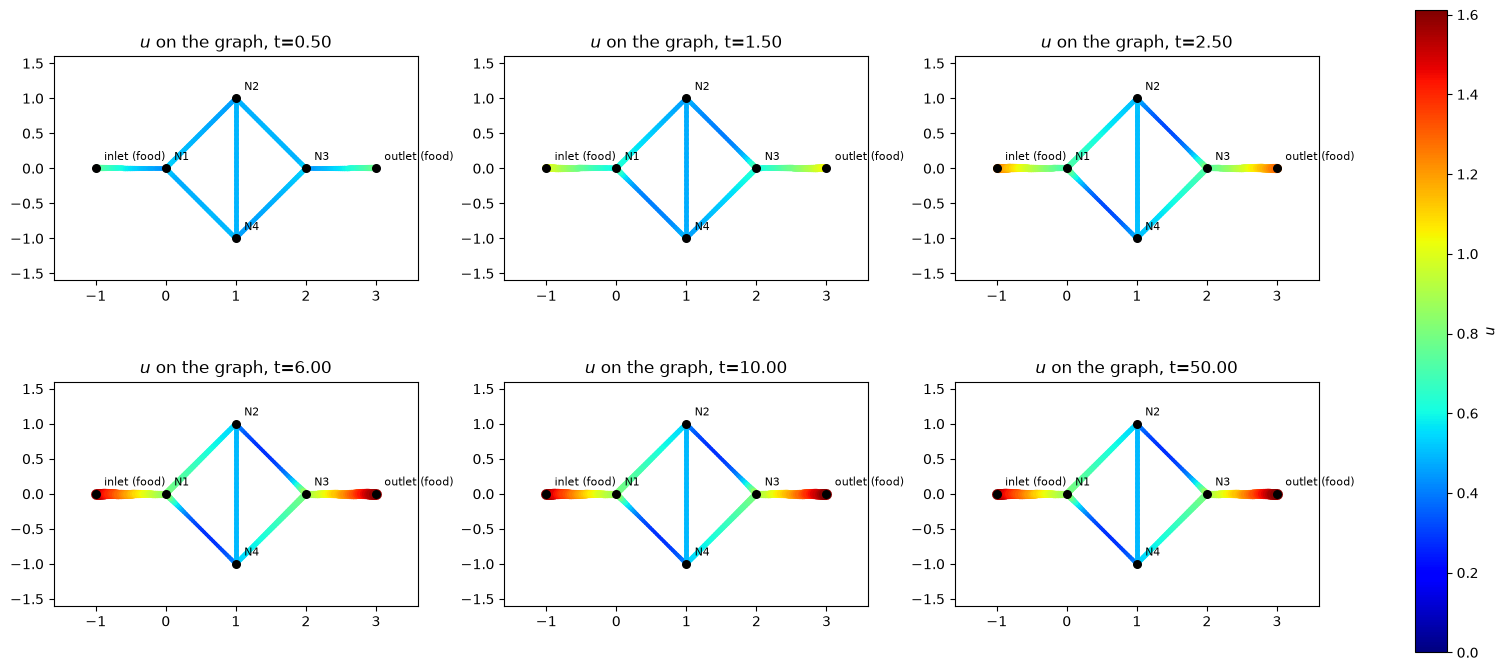

In [5]:
# Positions keyed by internal-node index (N1..N4 -> 0..3) or external end (arc, side)
node_pos = {
    0: (0.0, 0.0),             # N1
    1: (1.0, 1.0),             # N2
    2: (2.0, 0.0),             # N3
    3: (1.0, -1.0),            # N4
    (0, "left"): (-1.0, 0.0),  # inlet
    (6, "right"): (3.0, 0.0),  # outlet
}
node_labels = {p: name for p, name in enumerate(node_endpoints)} | {
    (0, "left"): "inlet (food)",
    (6, "right"): "outlet (food)",
}

paper_times = [0.5, 1.5, 2.5, 6, 10, 50]
snapshot_indices = [min(round(t / k), n_time_steps - 1) for t in paper_times]

plot_density_snapshots(
    node_pos, internal_nodes, external_bcs, u_minus, u_plus, snapshot_indices, k,
    node_labels=node_labels,
)
plt.show()